# Tutorial: optimize a Neural Topic Model (Neural LDA) with OCTIS

Welcome! guys This is a tutorial that allows you to optimize the hyperparameters of a neural topic model using OCTIS (Optimizing and Comparing Topic Models Is Simple).

![](https://github.com/MIND-Lab/OCTIS/blob/master/logo.png?raw=true)

A topic model allows you to discover the latent topics in your documents in a completely unsupervised way. But to find the best results, you usually need to optimize its hyperparameters.

## Enabling the GPU

First, you'll need to enable GPUs for the notebook:

- Navigate to Edit→Notebook Settings
- select GPU from the Hardware Accelerator drop-down

[Reference](https://colab.research.google.com/notebooks/gpu.ipynb)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Installing OCTIS

We need to install OCTIS. (We are going to use the library version of OCTIS, but you can also use it through its dashboard. See https://github.com/mind-Lab/octis for more details.)

In [ ]:
!pip install octis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.0/131.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 37.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 20.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 48.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.6/170.6 kB 16.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 62.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.6 MB/s eta 0:00:00
  Created wheel for libsvm: filename=libsvm-3.23.0.4-cp310-cp310-linux_x86_64.whl size=251408 sha256=b611015a127904a5d683dbf450fdaa411fd8ae3e1cfedc7f7a6fd9ca587ccbf0
  Stored in directory

Let's import what we need.

In [ ]:
from octis.models.NeuralLDA import NeuralLDA
from octis.dataset.dataset import Dataset
from octis.optimization.optimizer import Optimizer
from skopt.space.space import Real, Categorical, Integer
from octis.evaluation_metrics.coherence_metrics import Coherence
from octis.evaluation_metrics.diversity_metrics import TopicDiversity


## Load Data
We need some data to run a topic model. load custom dataset

In [ ]:
# Define dataset
dataset = Dataset()
dataset.load_custom_dataset_from_folder('/content/drive/MyDrive/octis_format_UNTM/Neural')

## Load Topic Model


In [ ]:
# For UDC Dataset
# model = NeuralLDA(num_topics=5, dropout=0.09, num_layers=1, num_neurons=300  )

In [ ]:
model = NeuralLDA(num_topics=7, dropout=0.104, num_layers=3, num_neurons=100  )

In [ ]:
# arguments of NeuralLDA
import inspect
print(inspect.getsource(NeuralLDA))

class NeuralLDA(AVITM):
    def __init__(
        self, num_topics=10, activation='softplus', dropout=0.2,
        learn_priors=True, batch_size=64, lr=2e-3, momentum=0.99,
        solver='adam', num_epochs=100, reduce_on_plateau=False, prior_mean=0.0,
        prior_variance=None, num_layers=2, num_neurons=100, num_samples=10,
            use_partitions=True):
        super().__init__(
            num_topics=num_topics, model_type='LDA', activation=activation,
            dropout=dropout, learn_priors=learn_priors, batch_size=batch_size,
            lr=lr, momentum=momentum, solver=solver, num_epochs=num_epochs,
            reduce_on_plateau=reduce_on_plateau, prior_mean=prior_mean,
            prior_variance=prior_variance, num_layers=num_layers,
            num_neurons=num_neurons, num_samples=num_samples,
            use_partitions=use_partitions)

    def train_model(self, dataset, hyperparameters=None, top_words=10):
        return super().train_model(
            dataset=dataset,

In [ ]:
# Train the model using default partitioning choice
output = model.train_model(dataset)

print(*list(output.keys()), sep="\n") # Print the output identifiers

Epoch: [1/100]	Samples: [6392/639200]	Train Loss: 1344.6550693249374	Time: 0:00:24.573217
Epoch: [1/100]	Samples: [799/79900]	Validation Loss: 1288.5244250625783	Time: 0:00:00.827785
Epoch: [2/100]	Samples: [12784/639200]	Train Loss: 1300.8542721859355	Time: 0:00:23.888944
Epoch: [2/100]	Samples: [799/79900]	Validation Loss: 1293.7847651361076	Time: 0:00:00.750798
Epoch: [3/100]	Samples: [19176/639200]	Train Loss: 1286.1797975007821	Time: 0:00:21.558468
Epoch: [3/100]	Samples: [799/79900]	Validation Loss: 1282.9638415206507	Time: 0:00:00.726940
Epoch: [4/100]	Samples: [25568/639200]	Train Loss: 1278.5050331469024	Time: 0:00:22.563317
Epoch: [4/100]	Samples: [799/79900]	Validation Loss: 1278.0815032462453	Time: 0:00:00.759536
Epoch: [5/100]	Samples: [31960/639200]	Train Loss: 1272.6113794586984	Time: 0:00:20.761126
Epoch: [5/100]	Samples: [799/79900]	Validation Loss: 1271.743590621089	Time: 0:00:00.718683
Epoch: [6/100]	Samples: [38352/639200]	Train Loss: 1270.7513456762358	Time: 0:00:2

In [ ]:
for t in output['topics'][:7]:
  print(" ".join(t))

ایکسپورٹرز ٹھوس انعامات صدارتی تحقیقی بیشتر مانیٹرنگ اختیارات کاغذات عہدیداروں
سونے چاہیئے پلائیں شب چلنا سازگار افسوس گورننس نعمان کڑی
بالی فلم سالہ ووڈ نیوزی اداکار لینڈ فلموں اداکارہ سیریز
مطابق پاکستان گزشتہ پہلے موجود کمی دوران شامل سامنے لیگ
لائیں مختار مدعو انتظامی ایشنز زیراہتمام کیش کیاگیا ترکیہ امان
خراج رجوع حنیف کردیں اٹھاتے برعکس سبی جھگڑے ضوابط حاجی
غربت مخالفین رجحانات سردار سیاستدان پیشرفت الیکٹرک ناکامی خزانے آروائی


In [ ]:
# Initialize metric
cv = Coherence(texts=dataset.get_corpus(), topk=10, measure='c_v')

In [ ]:
# Initialize metric
topic_diversity = TopicDiversity(topk=10)

In [ ]:
# Retrieve metrics score
topic_diversity_score = topic_diversity.score(output)
print("Topic diversity: "+str(topic_diversity_score))

npmi_score = cv.score(output)
print("Coherence: "+str(npmi_score))

Topic diversity: 1.0
Coherence: 0.47612937891824725


In [ ]:
from octis.evaluation_metrics.diversity_metrics import InvertedRBO

In [ ]:
# Initialize metric
IRBO = InvertedRBO(topk=10, weight=0.9)

In [ ]:
# Retrieve metrics score
IRBO_score = IRBO.score(output)
print("Inverted RBO: "+str(IRBO_score))

Inverted RBO: 1.0


## Hyperparameter tuning on UNTM Dataset



In [ ]:
coherence = Coherence(texts=dataset.get_corpus(), measure ='c_v')

## Define Hyperparameter Search Space

Now we are going to define the search space for the optimization algorithm. We need to specify the type of each hyperparameter (`Categorical`, `Integer` or `Real`). If it's Categorical (e.g. the activation function), we need to list the possibile values, otherwise (e.g. the dropout) we specify the lower and upper bounds of the hyperparameter.

Note that we choose to define the number of neurons as categorical to reduce the search space. Instead of considering all the possible 200 values between 100 and 300, we reduce the search to possible 3 values.

In [ ]:
search_space = {"num_layers": Integer(1,3),
                "num_neurons": Categorical({100, 200, 300}),
                "dropout": Real(0.0, 0.95)}

In [ ]:
optimization_runs=20
model_runs=3

In [ ]:
extra_metrics = [cv,IRBO,topic_diversity]

In [ ]:
optimizer=Optimizer()
import time
start = time.time()
optimization_result = optimizer.optimize(
    model, dataset, coherence, search_space, number_of_call=optimization_runs,
    model_runs=model_runs, save_models=True,
    extra_metrics=extra_metrics, # to keep track of other metrics
    save_path='/content/drive/MyDrive/results/test_neuralLDA//')
end = time.time()
duration = end - start
optimization_result.save_to_csv("/content/drive/MyDrive/results_neuralLDA_UNTM.csv")
print('Optimizing model took: ' + str(round(duration)) + ' seconds.')

Current call:  0
Epoch: [1/100]	Samples: [6392/639200]	Train Loss: 1426.2401243742179	Time: 0:00:48.486609
Epoch: [1/100]	Samples: [799/79900]	Validation Loss: 1345.6333209480601	Time: 0:00:01.162313
Epoch: [2/100]	Samples: [12784/639200]	Train Loss: 1393.576977325172	Time: 0:00:43.137568
Epoch: [2/100]	Samples: [799/79900]	Validation Loss: 1343.9055362171464	Time: 0:00:01.563049
Epoch: [3/100]	Samples: [19176/639200]	Train Loss: 1385.032354896746	Time: 0:00:41.649624
Epoch: [3/100]	Samples: [799/79900]	Validation Loss: 1334.0487767913016	Time: 0:00:01.555238
Epoch: [4/100]	Samples: [25568/639200]	Train Loss: 1376.556173732791	Time: 0:00:44.766519
Epoch: [4/100]	Samples: [799/79900]	Validation Loss: 1327.4612943914267	Time: 0:00:01.103222
Epoch: [5/100]	Samples: [31960/639200]	Train Loss: 1372.1586162390488	Time: 0:00:44.320680
Epoch: [5/100]	Samples: [799/79900]	Validation Loss: 1325.5132440941802	Time: 0:00:01.117992
Epoch: [6/100]	Samples: [38352/639200]	Train Loss: 1364.45634802291

The summary of the results are stored in the file "results.json" in the results folder. But you can also save the main results of the optimization in a csv file.

## Analysis of the results

Let's inspect the optimization results. Just load the results file. This is the information that is stored.

In [ ]:
import json
results = json.load(open('/content/drive/MyDrive/results/test_neuralLDA/result.json' ,'r'))
results.keys()

dict_keys(['dataset_name', 'dataset_path', 'is_cached', 'kernel', 'acq_func', 'surrogate_model', 'optimization_type', 'model_runs', 'save_models', 'save_step', 'save_name', 'save_path', 'early_stop', 'early_step', 'plot_model', 'plot_best_seen', 'plot_name', 'log_scale_plot', 'search_space', 'model_name', 'model_attributes', 'use_partitioning', 'metric_name', 'extra_metric_names', 'metric_attributes', 'extra_metric_attributes', 'current_call', 'number_of_call', 'random_state', 'x0', 'y0', 'n_random_starts', 'initial_point_generator', 'topk', 'time_eval', 'dict_model_runs', 'f_val', 'x_iters'])

The key "x_iters" is a dictionary containing the values of a given hyperparameter for each iteration. For example, these are the evaluated values of the hyperparameter "activation" across all the iterations.

In [ ]:
results['time_eval']

[3457.970597743988,
 2742.1505031585693,
 1974.9174160957336,
 1947.0200843811035,
 1254.0426359176636,
 1674.3297491073608,
 1852.275273323059,
 876.8485882282257,
 1884.6006181240082,
 1386.3547523021698,
 1421.3284311294556,
 1464.9614644050598,
 1573.04763007164,
 1477.9920191764832,
 2926.902893304825,
 2490.4106409549713,
 1412.3439772129059,
 1162.203340768814,
 1123.5511274337769,
 1068.387999534607]

In [ ]:
sum(results['time_eval'])

35171.63974237442

In [ ]:
# res['x_iters']['activation']

And this is the values of the function across all the iterations. Just use the key "f_val".

In [ ]:
results['f_val']

[0.46941378777578635,
 0.4648332866986204,
 0.3284071042149837,
 0.4531416761584987,
 0.5126769476794811,
 0.3569594006714385,
 0.47574888952090316,
 0.4701296429068885,
 0.44731216225632087,
 0.37987684085815004,
 0.4620930652911199,
 0.4628481579772569,
 0.4404834326953176,
 0.430443847306513,
 0.5065900332060499,
 0.47393137026170523,
 0.5161741388846836,
 0.5097488878951277,
 0.5238286093963956,
 0.4920465774940825]

We can plot this to see the progress of the Bayesian optimization.  

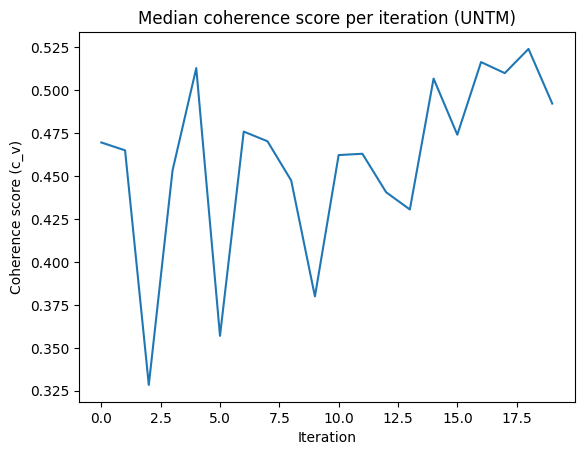

In [ ]:
import matplotlib.pyplot as plt
plt.xlabel('Iteration')
plt.ylabel('Coherence score (c_v)')
plt.title('Median coherence score per iteration (UNTM)')
plt.plot(results['f_val'])
plt.savefig('coherence_CV(UNTM).png')
plt.show()

In [ ]:
results['f_val'].index(max(results['f_val']))

18

In [ ]:
results["f_val"][18]

0.5238286093963956

In [ ]:
results['x_iters'].keys()

dict_keys(['dropout', 'num_layers', 'num_neurons'])

In [ ]:
print([results['x_iters'][parameter][18] for parameter in results['x_iters'].keys()])

[0.1042288659937763, 3, 100]


## Hyperparameter tuning on UDC Dataset



In [ ]:
coherence = Coherence(texts=dataset.get_corpus(), measure ='c_v')

## Define Hyperparameter Search Space

Now we are going to define the search space for the optimization algorithm. We need to specify the type of each hyperparameter (`Categorical`, `Integer` or `Real`). If it's Categorical (e.g. the activation function), we need to list the possibile values, otherwise (e.g. the dropout) we specify the lower and upper bounds of the hyperparameter.

Note that we choose to define the number of neurons as categorical to reduce the search space. Instead of considering all the possible 200 values between 100 and 300, we reduce the search to possible 3 values.

In [ ]:
search_space = {"num_layers": Integer(1,3),
                "num_neurons": Categorical({100, 200, 300}),
                "dropout": Real(0.0, 0.95)}

In [ ]:
optimization_runs=45
model_runs=1

In [ ]:
extra_metrics = [cv,IRBO,topic_diversity]

In [ ]:
optimizer=Optimizer()
import time
start = time.time()
optimization_result = optimizer.optimize(
    model, dataset, coherence, search_space, number_of_call=optimization_runs,
    model_runs=model_runs, save_models=True,
    extra_metrics=extra_metrics, # to keep track of other metrics
    save_path='results/test_neuralLDA//')
end = time.time()
duration = end - start
optimization_result.save_to_csv("results_CTM(UDC_MiniLM).csv")
print('Optimizing model took: ' + str(round(duration)) + ' seconds.')

Current call:  0
Current call:  1
Current call:  2
Current call:  3
Current call:  4
Current call:  5
Current call:  6
Current call:  7
Current call:  8
Current call:  9
Current call:  10
Current call:  11
Current call:  12
Current call:  13
Current call:  14
Current call:  15
Current call:  16
Current call:  17
Current call:  18
Current call:  19
Current call:  20
Current call:  21
Current call:  22
Current call:  23
Current call:  24
Current call:  25
Current call:  26
Current call:  27
Current call:  28
Current call:  29
Current call:  30
Current call:  31
Current call:  32
Current call:  33
Current call:  34
Current call:  35
Current call:  36
Current call:  37
Current call:  38
Current call:  39
Current call:  40
Current call:  41
Current call:  42
Current call:  43
Current call:  44
Optimizing model took: 6646 seconds.


## Analysis of the results

Let's inspect the optimization results. Just load the results file. This is the information that is stored.

In [ ]:
import json
results = json.load(open('results/test_neuralLDA/result.json' ,'r'))
results.keys()

dict_keys(['dataset_name', 'dataset_path', 'is_cached', 'kernel', 'acq_func', 'surrogate_model', 'optimization_type', 'model_runs', 'save_models', 'save_step', 'save_name', 'save_path', 'early_stop', 'early_step', 'plot_model', 'plot_best_seen', 'plot_name', 'log_scale_plot', 'search_space', 'model_name', 'model_attributes', 'use_partitioning', 'metric_name', 'extra_metric_names', 'metric_attributes', 'extra_metric_attributes', 'current_call', 'number_of_call', 'random_state', 'x0', 'y0', 'n_random_starts', 'initial_point_generator', 'topk', 'time_eval', 'dict_model_runs', 'f_val', 'x_iters'])

The key "x_iters" is a dictionary containing the values of a given hyperparameter for each iteration. For example, these are the evaluated values of the hyperparameter "activation" across all the iterations.

In [ ]:
results['time_eval']

[271.6166443824768,
 123.99028539657593,
 140.25200033187866,
 134.48146724700928,
 89.9791624546051,
 376.5875196456909,
 133.88397026062012,
 135.8484389781952,
 127.87270712852478,
 161.82943749427795,
 127.08956742286682,
 80.46700358390808,
 110.3324327468872,
 141.01036262512207,
 77.6193037033081,
 205.63549423217773,
 120.48742294311523,
 143.71613001823425,
 145.24342679977417,
 141.73721837997437,
 98.17431330680847,
 192.89780044555664,
 100.91395711898804,
 116.93903636932373,
 132.86624264717102,
 111.80434608459473,
 206.15241503715515,
 351.1818280220032,
 175.02291822433472,
 275.07682824134827,
 58.73817157745361,
 225.43784022331238,
 105.40386152267456,
 72.46832966804504,
 108.3351662158966,
 70.82757353782654,
 110.47482752799988,
 80.89296293258667,
 205.89322209358215,
 133.4743356704712,
 149.4889862537384,
 101.75462460517883,
 295.64462637901306,
 60.12052392959595,
 116.54071259498596]

In [ ]:
sum(results['time_eval'])

6646.205446004868

And this is the values of the function across all the iterations. Just use the key "f_val".

In [ ]:
results['f_val']

[0.6215523867580515,
 0.636084138068522,
 0.5337372298667097,
 0.5860658469837036,
 0.650099840225211,
 0.4610746386247141,
 0.5845533991577457,
 0.6777804673433516,
 0.5158039238080481,
 0.5560977524394424,
 0.5758167478457571,
 0.5509074927282899,
 0.5610437368374416,
 0.37658068201096395,
 0.5453218043658946,
 0.5364407775615023,
 0.5177406804044522,
 0.4688121737807128,
 0.47284635877290865,
 0.38488852081518743,
 0.5935458303901979,
 0.6002834483242833,
 0.536670512046538,
 0.5759937720511624,
 0.6486022898617174,
 0.5206556613811997,
 0.6280586629878137,
 0.6496282216292464,
 0.6019335947188612,
 0.5696322828976016,
 0.5883929673663024,
 0.5337274465818088,
 0.5365711534996714,
 0.5024369379907512,
 0.5641349977340202,
 0.6425430094871148,
 0.47730801245963905,
 0.5963723978919242,
 0.55548912543187,
 0.5174570575134381,
 0.47954779455999397,
 0.5793482879496491,
 0.6068749568496852,
 0.5956780027715336,
 0.6693276863565716]

We can plot this to see the progress of the Bayesian optimization.  

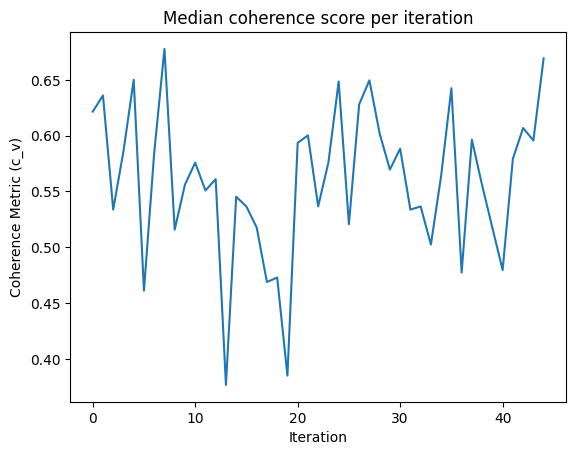

In [ ]:
import matplotlib.pyplot as plt
plt.xlabel('Iteration')
plt.ylabel('Coherence Metric (c_v)')
plt.title('Median coherence score per iteration')
plt.plot(results['f_val'])
plt.savefig('coherence_CV(UDC_MiniLM).png')
plt.show()

In [ ]:
results['f_val'].index(max(results['f_val']))

7

In [ ]:
results["f_val"][7]

0.6777804673433516

In [ ]:
results['x_iters'].keys()

dict_keys(['dropout', 'num_layers', 'num_neurons'])

In [ ]:
print([results['x_iters'][parameter][7] for parameter in results['x_iters'].keys()])

[0.7319653704814311, 2, 100]
